In [45]:
from pathlib import Path
import random
from pprint import pprint
import logging
from IPython.display import display, Markdown
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

---
---
### Colab config

In [46]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [47]:
# BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/notebooks"
# os.chdir(BASE_DIR)

---
---

In [48]:
Path.cwd()

WindowsPath('c:/Projects/KINECTRICS/Anomaly-Detection/notebooks')

## Initial configurations

In [49]:
#-------------------------------------------------------------------------------
# Paths
#-------------------------------------------------------------------------------

DATA_DIR = Path("../data/side/data_jpg_crop_512x512").resolve()
print(DATA_DIR, '\n')
CLEAN_DIRS  = DATA_DIR / 'clean_train'
DEFECT_DIRS = DATA_DIR / 'defect_test'
print(CLEAN_DIRS)
print(DEFECT_DIRS)

#-------------------------------------------------------------------------------
# Constants
#-------------------------------------------------------------------------------

SEED = 42
IMG_SIZE = (512, 512)
CORRUPTION_FACTOR = 0.5 # Higher → more corruption. 0.5 means the noise will have a stddev of 0.5, which is quite high for pixel values in [0,1]. Adjust as needed.
BATCH_SIZE = 8
EPOCHS = 40
VAL_SPLIT = 0.15
AUTOTUNE = tf.data.AUTOTUNE # -1

VALID_EXTS = {".jpg", ".jpeg"}
SKIP_DIRS = ['Flagged']

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512 

C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512\clean_train
C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512\defect_test


---
# 1. Data Preparation
---

<span style='color:yellow'> Before moving on: </span>
> The following functions from `list_files` to `create_dataset` are defined in `data.py` since they are shared between notebooks. However, they are still included here for **pedagogical purposes and to make this notebook self-contained**. They are marked with `--- IGNORE ---` to indicate that they are not part of the core logic of this notebook and can be skipped when reading for understanding the anomaly detection process.

### List paths:

In [ ]:
# --- IGNORE ---
def list_files(directory: Path) -> list[Path]:
    """ Returns the list of paths of all the images in the given directory and subdirectories. """
    files = []
    n = 0
    for root, dirs, filenames in os.walk(directory):
        # Modify 'dirs' in place so certain folders are exluded from the search:
        dirs[ : ] = [d for d in dirs if d not in SKIP_DIRS]
        for fl in filenames:
            if Path(fl).suffix.lower() not in VALID_EXTS: # skip non-image files
                n+=1
                continue
            files.append(Path(root) / fl)
    print(f'{n} invalid-format image files were skipped') if n > 0 else print('All images have valid formats')
    files.sort()
    return files

In [51]:
data_images = list_files(CLEAN_DIRS)
print(f'{len(data_images)} clean images where found in {CLEAN_DIRS} directory')

C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512\clean_train
C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512\clean_train\clean_missplaced
C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512\clean_train\clean_new
C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512\clean_train\clean_v1
C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512\clean_train\clean_v2
All images have valid formats
196 clean images where found in C:\Projects\KINECTRICS\Anomaly-Detection\data\side\data_jpg_crop_512x512\clean_train directory


In [52]:
random.shuffle(data_images)
n_val = int(len(data_images) * VAL_SPLIT)

train_paths = data_images[n_val:]
val_paths = data_images[:n_val]

print(f'{len(train_paths)} training images and {len(val_paths)} validation images')

167 training images and 29 validation images


### Load Data:
`tf.oi` is the tensorflow module for input/output operations. Is the module of tensorflow for reading, writing, parsing and transforming data:

In [53]:
# --- IGNORE ---
def _load_image_tf(tf_path: tf.Tensor) -> tf.Tensor:
    ''' Loads an image from the given path and preprocesses it for training. Only supports JPG images.
    Returns a tensor of shape (H, W, 3) and dtype float32 with pixel values in [0,1]. '''
    image_bytes = tf.io.read_file(tf_path) # read the image file as a bytes string
    image = tf.image.decode_jpeg(image_bytes, channels=3) # decode the bytes string into a tensor of shape (H, W, 3) and dtype uint8
    image = tf.image.convert_image_dtype(image, tf.float32)  # Rescale to [0,1] (better for training)
    image = tf.image.resize(image, IMG_SIZE) # Since the image is already square, the resizing will not distort the image
    return image

### Add noise to the images:

In [54]:
# --- IGNORE ---
def _add_mild_corruption(image: tf.Tensor, corruption_factor: float) -> tf.Tensor:
    ''' Adds mild corruption to the given image tensor. Returns a corrupted image tensor of the same shape and dtype as the input, with pixel values in [0,1]. '''
    x = image
    # Mild Gaussian noise
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=corruption_factor, dtype=tf.float32)
    x = x + noise # Add noise. Can push pixels outside [0,1].
    x = tf.clip_by_value(x, 0.0, 1.0) # Ensure pixel values are still in [0,1]. If p > 1 → 1, if p < 0 → 0.

    # Mild brightness variation
    x = tf.image.random_brightness(x, max_delta=0.05)
    x = tf.clip_by_value(x, 0.0, 1.0)

    # Mild contrast variation
    x = tf.image.random_contrast(x, lower=0.95, upper=1.05)
    x = tf.clip_by_value(x, 0.0, 1.0)

    return x

In [55]:
# --- IGNORE ---
def corrupt_and_clean_from_path(tf_path: tf.Tensor, corruption_factor: float,
                                ) -> tuple[tf.Tensor, tf.Tensor]:
    ''' Loads the image at the given path, creates a mildly corrupted version of it, and returns both the corrupted and clean images as tensors. '''
    clean = _load_image_tf(tf_path)
    corrupted = _add_mild_corruption(clean, corruption_factor)
    return corrupted, clean

### Lazy loading and on-the-fly corruption of the images during training:
`tf.data.Dataset` is the main class of the module. It is not a data container but a **data transformation pipeline**. The object `Dataset` is an iterable, processes elements lazily (on-the-fly) as they are requested:
- `map` transforms each element of the dataset **on-the-fly.**
- `batch` groups elements into batches for efficient computation during training.
- `prefetch` optimizes the process. Allows the data pipeline to prepare the next batch while the current batch is being processed by the model, reducing idle time.
    - e.g., CPU prepares data while GPU (or CPU) processes the current batch

Without `tf.data`:
- All the data is loaded in the RAM.
- Data pipelines are typically less efficient.
- No automatic parallelism or overlap between preprocessing and model execution.

<span style='color:yellow'> Note: </span> A `Dataset` behaves similarly to a Python **generator**, but supports parallelism, optimization, and complex transformations

In [56]:
# --- IGNORE ---
def create_dataset(paths: list[Path], 
                   shuffle: bool = True, 
                   corruption_factor: float = 0.5) -> tf.data.Dataset:
  # Create a dataset with the list of paths (elements will be tf.Tensors):
  lazy_ds = tf.data.Dataset.from_tensor_slices([str(p) for p in paths])
  # Shuffles (only the paths, not the images yet) to ensure random order at each epoch during training:
  lazy_ds = (lazy_ds.shuffle(buffer_size=len(paths), seed=SEED)) if shuffle else lazy_ds
  # Apply corruption and loading in parallel to speed up the data pipeline:
  lazy_ds = lazy_ds.map(lambda x: corrupt_and_clean_from_path(x, corruption_factor), 
                        num_parallel_calls=AUTOTUNE) # x is a tf.Tensor
  # Each element of the dataset is now a tuple (corrupted_image, clean_image)
  
  # Batch the dataset:
  lazy_ds = lazy_ds.batch(BATCH_SIZE)
  # Prefetch to improve performance:
  lazy_ds = lazy_ds.prefetch(AUTOTUNE)

  return lazy_ds

Create the data bases for train and validation sets:

In [57]:
train_ds = create_dataset(train_paths, shuffle=True, corruption_factor=0.5)
val_ds = create_dataset(val_paths, shuffle=False, corruption_factor=0.5)

Display some examples of the corrupted and clean images from the training dataset:

In [58]:
def show_batch_examples(dataset: tf.data.Dataset, n: int = 3) -> None:
    batch_x, batch_y = next(iter(dataset))

    plt.figure(figsize=(12, 4 * n))
    for i in range(n):
        # Corrupted
        plt.subplot(n, 2, 2 * i + 1) # The 3rd argument is the index of the subplot. +1 means to plot always in the first column.
        plt.imshow(batch_x[i].numpy()) # Convert the tensor to a numpy array for plotting. The pixel values are still in [0,1], but plt.imshow interprets them correctly using the dtype and range. Rescales the data accordingly to [0,255].
        plt.title("Input corrupted")
        plt.axis("off")

        # Clean
        plt.subplot(n, 2, 2 * i + 2) # +2 means to plot always in the second column.
        plt.imshow(batch_y[i].numpy())
        plt.title("Target clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

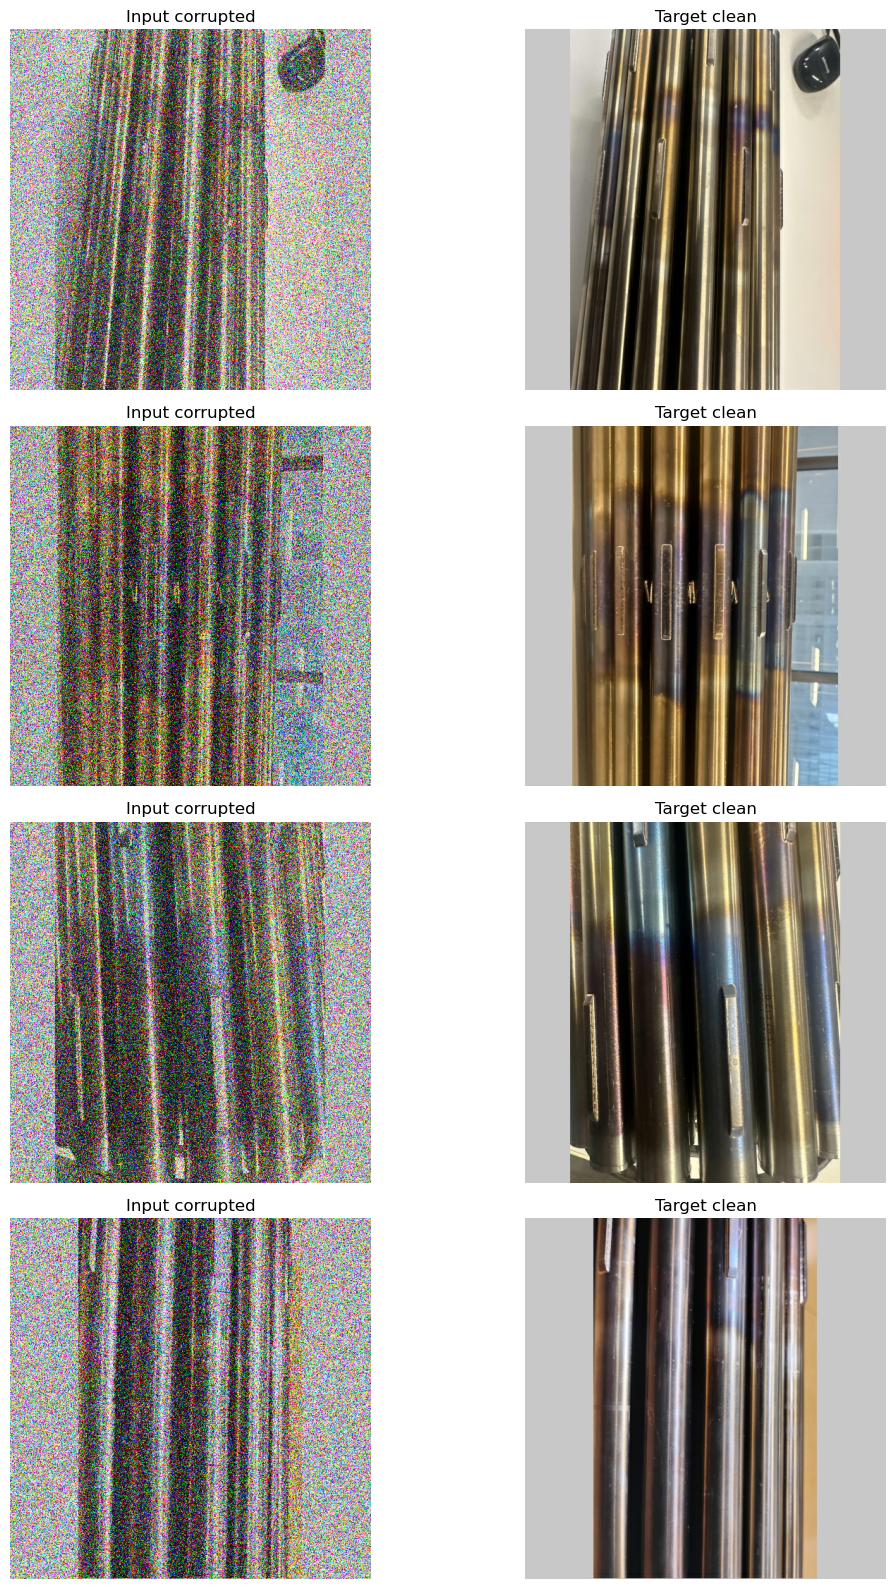

In [59]:
show_batch_examples(train_ds, n=4)

---
# 2. Model Definition and Training
---

### Encoder-decoder convolutional with U-net skip type:

In [ ]:
def _conv_block(x: tf.Tensor, filters: int, kernel_size: int = 3) -> tf.Tensor:
    ''' A convolutional block consisting of two Conv2D layers, each followed by 
    BatchNormalization and ReLU activation. Returns the output tensor after applying 
    the block. '''
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

In [ ]:
def build_unet_dae(input_shape: tuple[int, int, int] = (512, 512, 3)) -> keras.Model:
    ''' Builds a U-Net architecture for a denoising autoencoder. The model takes an input 
    image of the specified shape and outputs a denoised image of the same shape. Returns 
    the model. '''
    inputs = keras.Input(shape=input_shape)

    # Encoder
    c1 = _conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = _conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = _conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    c4 = _conv_block(p3, 256)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = _conv_block(p4, 512)

    # Decoder
    u4 = layers.UpSampling2D()(bn)
    u4 = layers.Concatenate()([u4, c4])
    c5 = _conv_block(u4, 256)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = _conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = _conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = _conv_block(u1, 32)

    outputs = layers.Conv2D(3, 1, activation="sigmoid", padding="same")(c8)

    model = keras.Model(inputs, outputs, name="unet_dae")
    return model

In [ ]:
model = build_unet_dae(input_shape=(*IMG_SIZE, 3))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mae",
    metrics=["mse"],
)

model.summary()

Model: "unet_dae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 512, 512,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_36 (ReLU)     │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 512, 512,  │      9,248 │ re_lu_36[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_37 (ReLU)     │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 256, 256,  │          0 │ re_lu_37[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 256, 256,  │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_38 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 256, 256,  │     36,928 │ re_lu_38[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_39 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 128, 128,  │          0 │ re_lu_39[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_42[0][0] 

 Total params: 7,858,499 (29.98 MB)

 Trainable params: 7,852,611 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
checkpoint_path = "../.models/unet_dae.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=2,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=2,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        verbose=2,
    ),
]

### Train the model

In [23]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/40

Epoch 1: val_loss improved from None to 0.24443, saving model to best_unet_dae.keras

Epoch 1: finished saving model to best_unet_dae.keras
25/25 - 82s - 3s/step - loss: 0.1598 - mse: 0.0433 - val_loss: 0.2444 - val_mse: 0.0750 - learning_rate: 1.0000e-04
Epoch 2/40

Epoch 2: val_loss improved from 0.24443 to 0.22020, saving model to best_unet_dae.keras

Epoch 2: finished saving model to best_unet_dae.keras
25/25 - 21s - 839ms/step - loss: 0.0864 - mse: 0.0124 - val_loss: 0.2202 - val_mse: 0.0673 - learning_rate: 1.0000e-04
Epoch 3/40

Epoch 3: val_loss improved from 0.22020 to 0.17275, saving model to best_unet_dae.keras

Epoch 3: finished saving model to best_unet_dae.keras
25/25 - 21s - 850ms/step - loss: 0.0659 - mse: 0.0078 - val_loss: 0.1728 - val_mse: 0.0429 - learning_rate: 1.0000e-04
Epoch 4/40

Epoch 4: val_loss did not improve from 0.17275
25/25 - 20s - 805ms/step - loss: 0.0583 - mse: 0.0064 - val_loss: 0.1822 - val_mse: 0.0527 - learning_rate: 1.0000e-04
Epoch 

In [24]:
def plot_history(history: keras.callbacks.History) -> None:
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training history")
    plt.legend()
    plt.grid(True)
    plt.show()

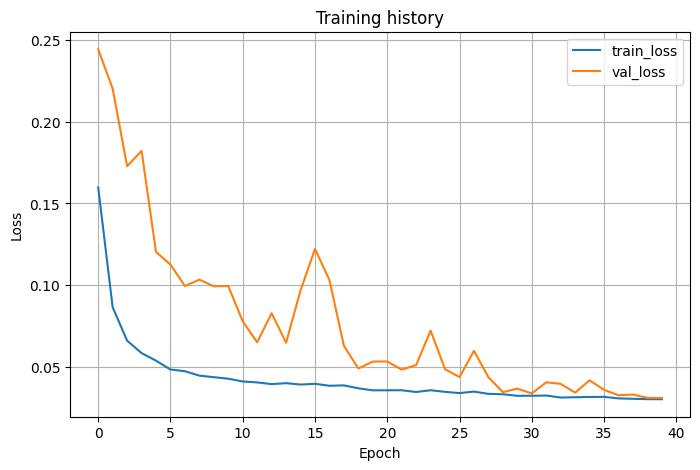

In [26]:
plot_history(history)